# Load data

In [1]:
%matplotlib inline
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

In [3]:
from os import listdir
from os.path import isfile, join
import numpy
from skimage import io
import torchvision

In [3]:
!nvidia-smi

Fri Jun  2 15:39:21 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.41.03              Driver Version: 530.41.03    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-PCIE-32GB            On | 00000000:58:00.0 Off |                    0 |
| N/A   32C    P0               38W / 250W|  14100MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [4]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on GPU.


In [5]:
import torchvision.transforms.functional as TTF
# https://discuss.pytorch.org/t/how-to-resize-and-pad-in-a-torchvision-transforms-compose/71850/5

image_size = 512

class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = np.max([w, h])
        hp = int((max_wh - w) / 2)
        vp = int((max_wh - h) / 2)
        padding = (hp, vp, hp, vp)
        return TTF.pad(image, padding, 0, 'constant')

# now use it as the replacement of transforms.Pad class
transform=transforms.Compose([
    SquarePad(),
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
#     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [6]:
batch_size = 64
trainset = torchvision.datasets.ImageFolder(root="/dtu/datasets1/02514/hotdog_nothotdog/train/", transform=transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=1)
testset = torchvision.datasets.ImageFolder(root="/dtu/datasets1/02514/hotdog_nothotdog/test/", transform=transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=1)

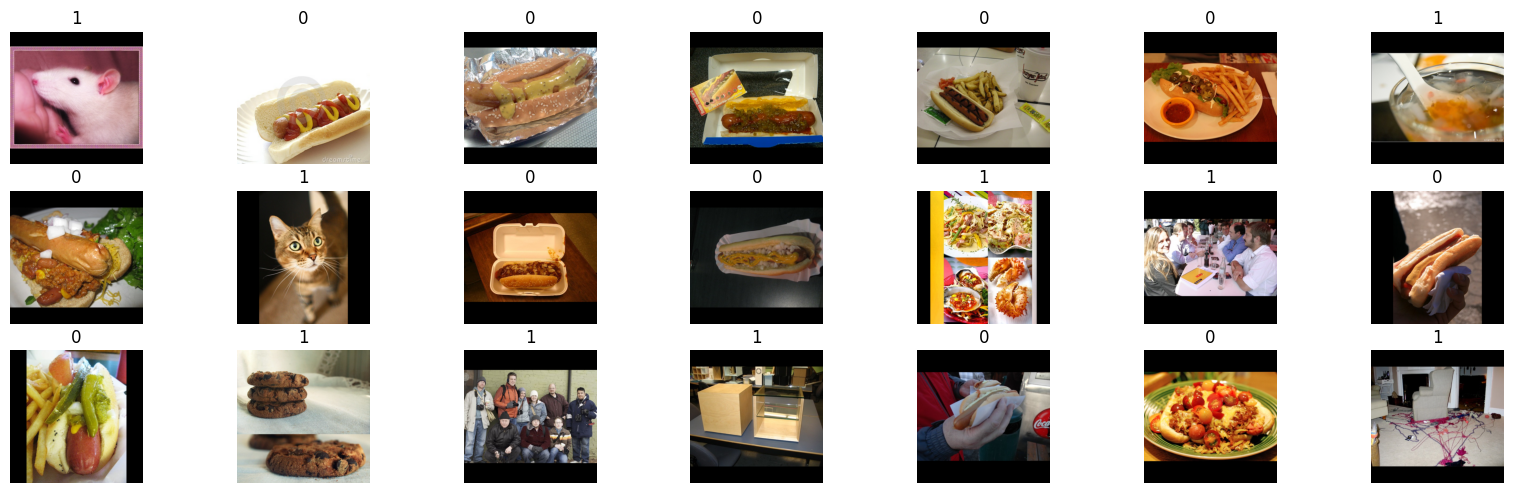

In [7]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
#     print(images[i].numpy()[0].shape)
    plt.imshow(images[i].numpy().transpose(1,2,0))#.reshape(512,512,3))
    plt.title(labels[i].item())
    plt.axis('off')

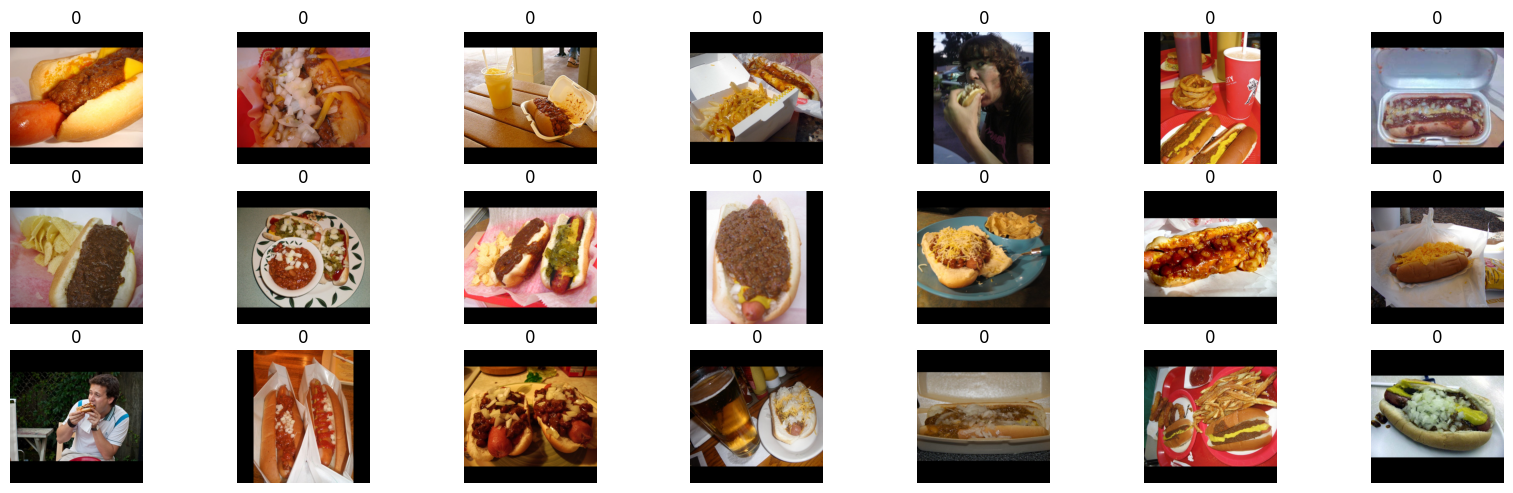

In [8]:
images, labels = next(iter(test_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
#     print(images[i].numpy()[0].shape)
    plt.imshow(images[i].numpy().transpose(1,2,0))#.reshape(512,512,3))
    plt.title(labels[i].item())
    plt.axis('off')

## Training

In [9]:
class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.convolutional = nn.Sequential(
                nn.Conv2d(3, 8, 3, stride=1, padding=1),
                nn.Conv2d(8, 8, 3, stride=1, padding=1),
                nn.MaxPool2d(2),
                nn.Conv2d(8, 16, 3, stride=1, padding=1),
                nn.Conv2d(16, 16, 3, stride=1, padding=1),
        )

        self.fully_connected = nn.Sequential(
                nn.Linear(256*256*16, 500),
                nn.ReLU(),
                nn.Linear(500, 10))
    
    def forward(self, x):
        x = self.convolutional(x)
        #reshape x so it becomes flat, except for the first dimension (which is the minibatch)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        return x

In [10]:
#We define the training as a function so we can easily re-use it.
def train(model, optimizer, num_epochs=10):
    def loss_fun(output, target):
        return F.cross_entropy(output, target)#F.nll_loss(torch.log(output), target)
    out_dict = {'train_acc': [],
              'test_acc': [],
              'train_loss': [],
              'test_loss': []}
  
    for epoch in tqdm(range(num_epochs), unit='epoch'):
        model.train()
        #For each epoch
        train_correct = 0
        train_loss = []
        for minibatch_no, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):
            data, target = data.to(device), target.to(device)
            #Zero the gradients computed for each weight
            optimizer.zero_grad()
            #Forward pass your image through the network
            output = model(data)
            #Compute the loss
            loss = loss_fun(output, target)
            #Backward pass through the network
            loss.backward()
            #Update the weights
            optimizer.step()

            train_loss.append(loss.item())
            #Compute how many were correctly classified
            predicted = output.argmax(1)
            train_correct += (target==predicted).sum().cpu().item()
        #Comput the test accuracy
        test_loss = []
        test_correct = 0
        model.eval()
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            with torch.no_grad():
                output = model(data)
            test_loss.append(loss_fun(output, target).cpu().item())
            predicted = output.argmax(1)
            test_correct += (target==predicted).sum().cpu().item()
        out_dict['train_acc'].append(train_correct/len(trainset))
        out_dict['test_acc'].append(test_correct/len(testset))
        out_dict['train_loss'].append(np.mean(train_loss))
        out_dict['test_loss'].append(np.mean(test_loss))
        print(f"Loss train: {np.mean(train_loss):.3f}\t test: {np.mean(test_loss):.3f}\t",
              f"Accuracy train: {out_dict['train_acc'][-1]*100:.1f}%\t test: {out_dict['test_acc'][-1]*100:.1f}%")
    return out_dict

In [14]:
model = Network()
model.to(device)
#Initialize the optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

#Get the first minibatch
data = next(iter(train_loader))[0].cuda()
#Try running the model on a minibatch
print('Shape of the output from the convolutional part', model.convolutional(data).shape)
model(data); #if this runs the model dimensions fit

Shape of the output from the convolutional part torch.Size([64, 16, 256, 256])


In [ ]:
#Initialize the optimizer
out_dict = train(model, optimizer)


  0%|          | 0/10 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 1.039	 test: 0.730	 Accuracy train: 52.7%	 test: 51.9%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.706	 test: 0.692	 Accuracy train: 54.8%	 test: 51.9%


...

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.678	 test: 0.686	 Accuracy train: 57.1%	 test: 51.2%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.684	 test: 0.683	 Accuracy train: 57.0%	 test: 52.6%


  0%|          | 0/32 [00:00<?, ?it/s]